In [1]:
import roboticstoolbox as rtb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# TODO: Fill in the correct parameters from the UR website

link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
# Create the robot object
my_ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

print(my_ur3e)

DHRobot: My_UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0921 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



In [3]:
# 1. Define Start and End joint configurations
q_start = np.array([0] * 6)           # Robot straight out
q_end   = np.array([4*np.pi] * 6) # Robot folded 90 degrees

# 2. Generate trajectory (50 steps)
traj = rtb.jtraj(q_start, q_end, 50)

# traj.q contains the 50x2 array of joint angles for the path
print("Shape of trajectory:", traj.q.shape)

# 3. Visualize the movement
# This will animate the robot moving through the path
# my_ur3e.plot(traj.q, backend='pyplot')

Shape of trajectory: (50, 6)


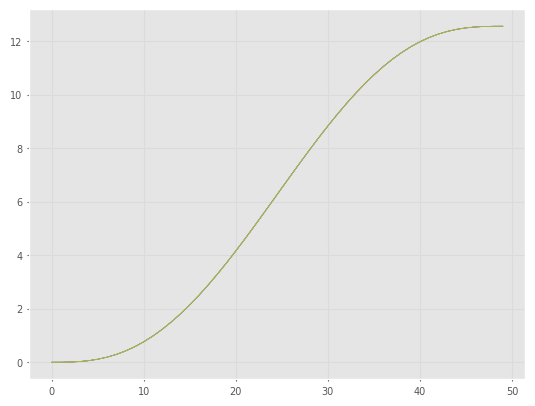

In [4]:
plt.plot(traj.q[:, :])

# Test Kinematic Model

The block below runs the FMU and tries to do some simple movements to indicate that the model works as we expect.

In [5]:
from kinematic_model import KinematicModel

In [6]:
model = KinematicModel(movement_fidelity=1000)

dt = 0.05
angle_history = []
for i in range(150):
    model.fmi2DoStep(i*dt, dt)
    if i == 10:
        model.fmi2SetCommandedJointAngles([np.pi/2] * 6)
    elif i == 100:
        model.fmi2SetCommandedJointAngles([np.pi/4] * 6)
    angle_history.append(model.current_joint_angles)
    

In [7]:
np.array(angle_history).shape

(150, 6)

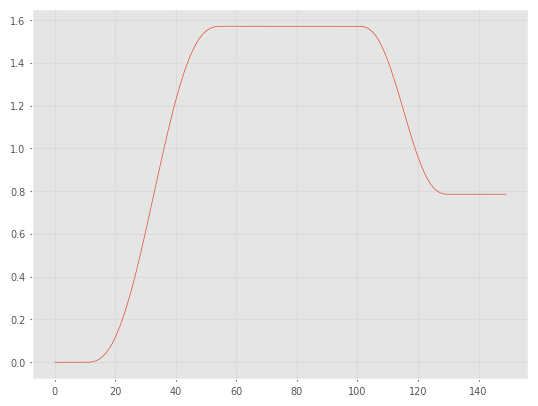

In [8]:
plt.plot(np.array(angle_history)[:, 0])